> Tarefa 1:

*   Disciplina: Física com Python 1 (2026.2) — CBPF
*   Autor: Gustavo Henrique Ribeiro
*   Obs: Código desenvolvido para fins de avaliação acadêmica. Disponibilizado publicamente sob a Licença MIT para consulta educacional.



##Q1

Aplique o **ridge-plot** (gráfico de cordilheira) para visualizar algum resultado da sua grande área de pesquisa.

**ridge-plot**:
*  https://seaborn.pydata.org/examples/kde_ridgeplot
*  https://python-graph-gallery.com/ridgeline-graph-seaborn/


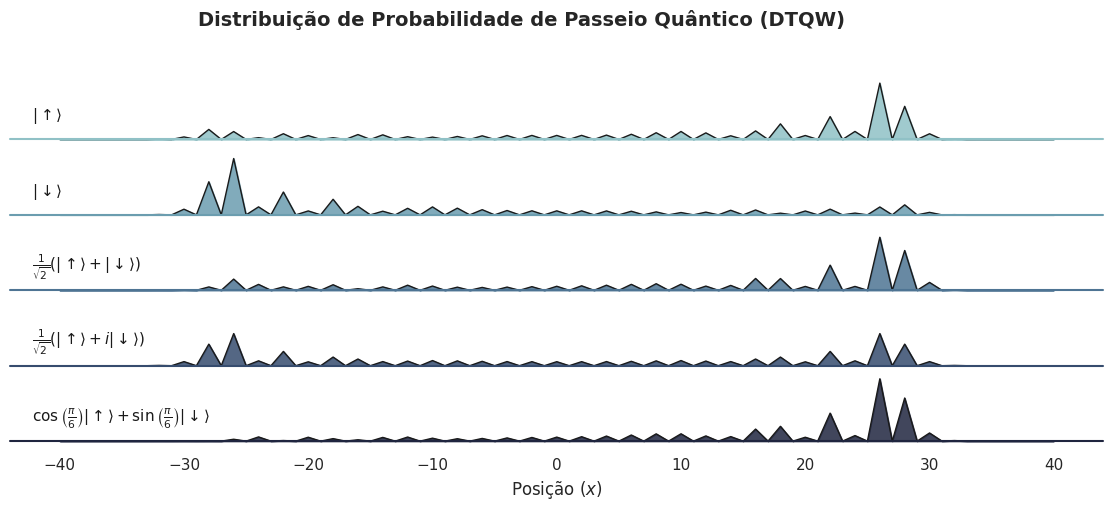

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração do tema estético
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# Parâmetros da simulação do Passeio Quântico (DTQW)
steps = 40
positions = np.arange(-steps, steps + 1)

# 5 Condições iniciais diferentes para o estado da moeda
initial_coins = [
    (np.array([1.0, 0.0], dtype=complex), r"$|\uparrow\rangle$"),
    (np.array([0.0, 1.0], dtype=complex), r"$|\downarrow\rangle$"),
    (np.array([1.0, 1.0], dtype=complex) / np.sqrt(2), r"$\frac{1}{\sqrt{2}}(|\uparrow\rangle + |\downarrow\rangle)$"),
    (np.array([1.0, 1.0j], dtype=complex) / np.sqrt(2), r"$\frac{1}{\sqrt{2}}(|\uparrow\rangle + i|\downarrow\rangle)$"),
    (np.array([np.cos(np.pi/6), np.sin(np.pi/6)], dtype=complex), r"$\cos\left(\frac{\pi}{6}\right)|\uparrow\rangle + \sin\left(\frac{\pi}{6}\right)|\downarrow\rangle$")
]

def simulate_qw(init_coin, steps):
    dim_pos = 2 * steps + 1
    psi = np.zeros((dim_pos, 2), dtype=complex)
    center_idx = steps
    psi[center_idx, :] = init_coin

    # Operador de Hadamard
    H = 1.0 / np.sqrt(2) * np.array([[1, 1], [1, -1]], dtype=complex)

    for t in range(steps):
        psi_coin = np.dot(psi, H.T)
        psi_next = np.zeros_like(psi)
        psi_next[1:, 0] = psi_coin[:-1, 0]
        psi_next[:-1, 1] = psi_coin[1:, 1]
        psi = psi_next

    prob = np.sum(np.abs(psi)**2, axis=1)
    return prob

# Construção do DataFrame estruturado para o FacetGrid
data = []
for init_coin, label in initial_coins:
    prob = simulate_qw(init_coin, steps)
    for p, pr in zip(positions, prob):
        data.append({"position": p, "probability": pr, "condition": label})

df = pd.DataFrame(data)

# Inicialização do FacetGrid com maior altura por linha
pal = sns.cubehelix_palette(len(initial_coins), rot=-.25, light=.7)
g = sns.FacetGrid(df, row="condition", hue="condition", aspect=12, height=1.0, palette=pal)

# Função de mapeamento para desenhar as distribuições
def plot_qw(position, probability, **kwargs):
    ax = plt.gca()
    color = kwargs.get('color', 'b')
    ax.fill_between(position, 0, probability, color=color, alpha=0.85, clip_on=False)
    ax.plot(position, probability, color="k", lw=1.0, clip_on=False)

g.map(plot_qw, "position", "probability")

# Linha de base para cada eixo
g.refline(y=0, linewidth=1.5, linestyle="-", color=None, clip_on=False)

# Função para posicionar os rótulos textuais
def label(x, color, label):
    ax = plt.gca()
    ax.text(0.02, 0.4, label, fontweight="bold", color="k",
            ha="left", va="center", transform=ax.transAxes, fontsize=11)

g.map(label, "position")

# Aumento do espaçamento vertical (hspace positivo/neutro)
g.figure.subplots_adjust(hspace=0.1)

# Remoção de detalhes e formatação final
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
g.set_axis_labels("Posição ($x$)", "")

# 1. Adiciona o título geral acima da figura (o parâmetro 'y' controla a altura)
g.fig.suptitle(r"Distribuição de Probabilidade de Passeio Quântico (DTQW)", y=1.01, fontsize=14, fontweight='bold')

# 2. Ajusta o espaçamento superior (top) e o espaçamento entre as faixas (hspace)
g.figure.subplots_adjust(top=0.88, hspace=0.1)

# Salvando a figura com o título ajustado
plt.savefig("quantum_walk_ridge_spaced.png", dpi=300, bbox_inches='tight')
plt.show()

##Q2

Aplique o **ternary-plot** (gráfico ternário) para visualizar algum resultado da sua grande área de pesquisa.

**ternary-plot**:
*  https://plotly.com/python/ternary-plots/
*  https://www.geeksforgeeks.org/python/ternary-plots-in-plotly/


Sem desordem (balístico)            α = 2.000 ± 0.001
Desordem temporal (difusivo)        α = 1.026 ± 0.002
Desordem espacial (localizado)      α = 0.055 ± 0.024


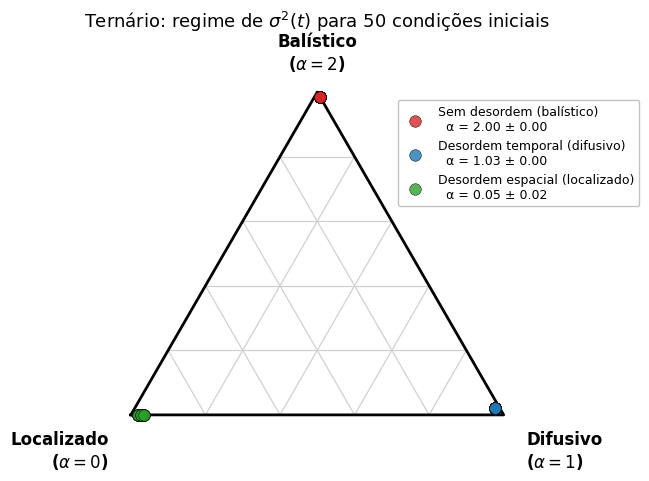

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

T      = 10**3 # número de passos
N_IC   = 50    # condições iniciais
N_REAL = 20    # realizações de desordem

N      = 2*T + 3
centro = N // 2
j      = np.arange(N) - centro

def condicoes_iniciais(n, rng):
    """n estados de spin uniformes na esfera de Bloch, localizados em j=0."""
    alpha = np.arccos(rng.uniform(-1, 1, n))
    phi   = rng.uniform(0, 2*np.pi, n)
    return np.cos(alpha/2), np.exp(1j*phi)*np.sin(alpha/2)

def variancia_passeio(a0, b0, tipo, T, n_real, rng):
    """Retorna variância σ²(t) com shape (n_ic, T+1), média sobre realizações."""
    n_ic = len(a0)
    R = 1 if tipo == 'sem' else n_real
    a = np.zeros((n_ic, R, N), complex)
    b = np.zeros((n_ic, R, N), complex)
    a[:, :, centro] = a0[:, None]
    b[:, :, centro] = b0[:, None]
    if tipo == 'espacial':
        theta_j = rng.uniform(0, np.pi/2, (1, R, N))

    var = np.zeros((n_ic, T+1))
    def registrar(t):
        p  = np.abs(a)**2 + np.abs(b)**2
        m1 = (p * j).sum(-1)
        m2 = (p * j**2).sum(-1)
        var[:, t] = (m2 - m1**2).mean(axis=1)

    registrar(0)
    for t in range(1, T+1):
        if tipo == 'sem':
            th = np.pi / 4
        elif tipo == 'temporal':
            th = rng.uniform(0, np.pi/2, (1, R, 1))
        else:
            th = theta_j
        c, s = np.cos(th), np.sin(th)
        a_new = c*a + s*b
        b_new = s*a - c*b
        a = np.roll(a_new,  1, axis=-1)
        b = np.roll(b_new, -1, axis=-1)
        registrar(t)
    return var

a0, b0 = condicoes_iniciais(N_IC, rng)

tipos = {
    'sem':      'Sem desordem (balístico)',
    'temporal': 'Desordem temporal (difusivo)',
    'espacial': 'Desordem espacial (localizado)',
}
var = {k: variancia_passeio(a0, b0, k, T, N_REAL, rng) for k in tipos}

# Ajuste do expoente α em σ² ~ t^α  (intervalo [T/5, T])
t_arr = np.arange(T+1)
sel   = t_arr >= T // 5

def expoente(v):
    return np.polyfit(np.log(t_arr[sel]), np.log(v[:, sel]).T, 1)[0]

alpha = {k: expoente(var[k]) for k in tipos}
for k in tipos:
    print(f"{tipos[k]:34s}  α = {alpha[k].mean():.3f} ± {alpha[k].std():.3f}")

cores = {
    'sem':      'tab:red',
    'temporal': 'tab:blue',
    'espacial': 'tab:green',
}

def pesos(alpha_arr, s=0.35):
    w = np.stack(
        [np.exp(-(alpha_arr - al)**2 / (2*s**2)) for al in (2, 1, 0)],
        axis=1,
    )
    return w / w.sum(1, keepdims=True)   # (balístico, difusivo, localizado)

def para_xy(w):
    # Vértices: localizado(0,0), difusivo(1,0), balístico(0.5, √3/2)
    x = w[:, 1] + 0.5 * w[:, 0]
    y = (np.sqrt(3) / 2) * w[:, 0]
    return x, y

fig, ax = plt.subplots(figsize=(7, 6.5))

# Triângulo externo
V = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2], [0, 0]])
ax.plot(V[:, 0], V[:, 1], 'k', lw=2)

# Grade interna (iso-peso em 20 %, 40 %, 60 %, 80 %)
for f in (0.2, 0.4, 0.6, 0.8):
    for pts in [
        np.array([[f,   1-f, 0  ], [f,   0,   1-f]]),  # w_bal = f
        np.array([[1-f, f,   0  ], [0,   f,   1-f]]),  # w_dif = f
        np.array([[1-f, 0,   f  ], [0,   1-f, f  ]]),  # w_loc = f
    ]:
        x, y = para_xy(pts)
        ax.plot(x, y, color='0.82', lw=0.9, zorder=1)

# Pontos das 50 condições iniciais por tipo
for k in tipos:
    x, y = para_xy(pesos(alpha[k]))
    ax.scatter(
        x, y,
        s=70, color=cores[k], alpha=0.80,
        edgecolor='k', lw=0.4,
        label=f"{tipos[k]}\n  α = {alpha[k].mean():.2f} ± {alpha[k].std():.2f}",
        zorder=3,
    )

# Rótulos dos vértices
ax.text(0.5,  np.sqrt(3)/2 + 0.05, 'Balístico\n($\\alpha=2$)',
        ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.text(1.06, -0.04, 'Difusivo\n($\\alpha=1$)',
        ha='left',   va='top',    fontsize=12, fontweight='bold')
ax.text(-0.06,-0.04, 'Localizado\n($\\alpha=0$)',
        ha='right',  va='top',    fontsize=12, fontweight='bold')

ax.set_aspect('equal')
ax.axis('off')
ax.set_title(
    'Ternário: regime de $\\sigma^2(t)$ para 50 condições iniciais',
    pad=35, fontsize=13,
)
ax.legend(
    loc='upper right', fontsize=9,
    bbox_to_anchor=(1.30, 0.95),
    framealpha=0.95, edgecolor='0.75',
)

fig.tight_layout()
plt.show()

##Q3

Faça um gráfico com **inset** para visualizar algum resultado da sua grande área de pesquisa.

Exemplo:
https://scipython.com/blog/inset-plots-in-matplotlib/

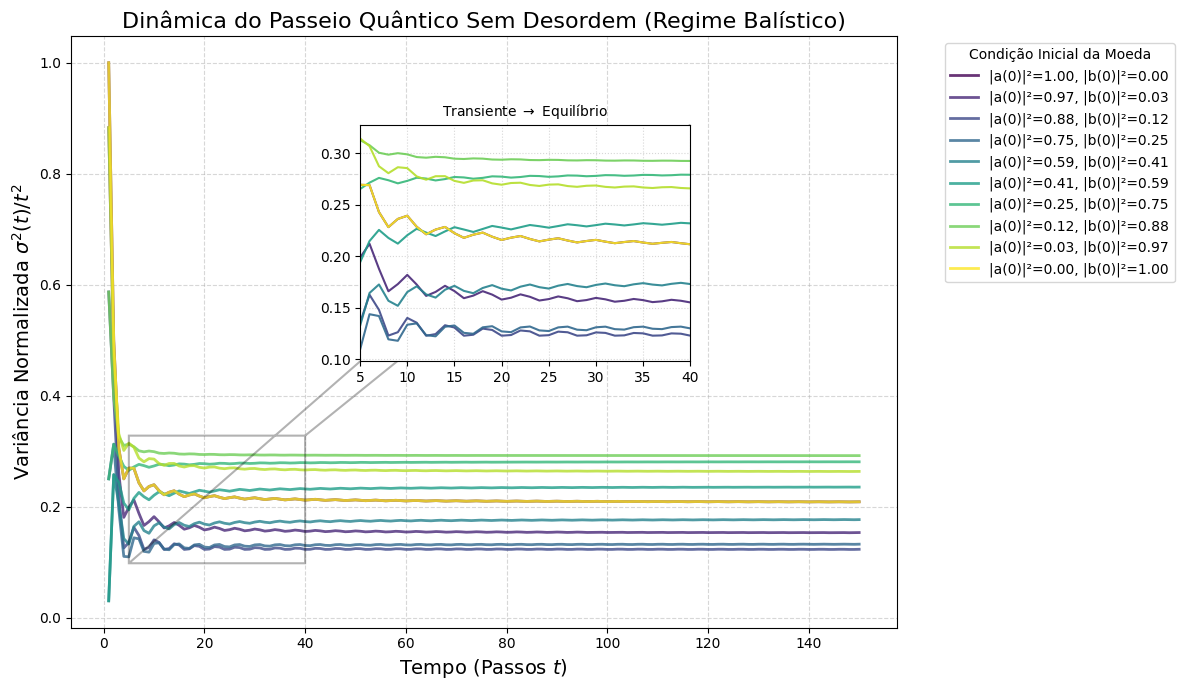

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ==========================================
# 1. Parâmetros da Simulação
# ==========================================
T_max = 150            # Tempo máximo de evolução
N = 2 * T_max + 1      # Tamanho da malha espacial
origem = T_max         # Posição central x=0
x = np.arange(-T_max, T_max + 1)  # Vetor de posições

num_condicoes = 10     # Número de condições iniciais diferentes

# Substituição moderna para evitar a mensagem de aviso (Deprecation Warning)
cores = mpl.colormaps['viridis'].resampled(num_condicoes)

# Gerando 10 condições iniciais variando o ângulo theta
# Estado inicial da moeda: cos(theta)|0> + sin(theta)|1>
thetas = np.linspace(0, np.pi/2, num_condicoes)

# Matrizes para armazenar o tempo e os valores de sigma^2 / t^2
tempos = np.arange(1, T_max + 1)
resultados_var_norm = np.zeros((num_condicoes, T_max))

# ==========================================
# 2. Loop de Simulação da Dinâmica Quântica
# ==========================================
for i, theta in enumerate(thetas):
    # Condição inicial da moeda (a_0 e b_0)
    a_0 = np.cos(theta)
    b_0 = np.sin(theta)

    Psi_Dir = np.zeros(N, dtype=complex)
    Psi_Esq = np.zeros(N, dtype=complex)

    # Aplicando a condição inicial na origem
    Psi_Dir[origem] = a_0
    Psi_Esq[origem] = b_0

    # Evolução temporal
    for t in range(1, T_max + 1):
        # Operador Moeda (Hadamard)
        nova_Dir = (Psi_Dir + Psi_Esq) / np.sqrt(2)
        nova_Esq = (Psi_Dir - Psi_Esq) / np.sqrt(2)

        # Operador Deslocamento Espacial (Shift)
        Psi_Dir = np.roll(nova_Dir, 1)
        Psi_Esq = np.roll(nova_Esq, -1)

        # Calculando Probabilidade P(x)
        P = np.abs(Psi_Dir)**2 + np.abs(Psi_Esq)**2

        # Momentos estatísticos
        media_x = np.sum(x * P)
        media_x2 = np.sum((x**2) * P)
        variancia = media_x2 - (media_x**2)

        # Armazena a variância normalizada por t^2
        resultados_var_norm[i, t-1] = variancia / (t**2)


# ==========================================
# 3. Plotagem com Inset (Zoom no Transiente)
# ==========================================
fig, ax = plt.subplots(figsize=(12, 7))

# Plotando as 10 curvas no gráfico principal
for i in range(num_condicoes):
    a_0_val = np.cos(thetas[i])
    b_0_val = np.sin(thetas[i])
    label_text = f'|a(0)|²={a_0_val**2:.2f}, |b(0)|²={b_0_val**2:.2f}'

    ax.plot(tempos, resultados_var_norm[i], color=cores(i), lw=2, alpha=0.8, label=label_text)

# Configurações do gráfico principal
ax.set_title('Dinâmica do Passeio Quântico Sem Desordem (Regime Balístico)', fontsize=16)
ax.set_xlabel('Tempo (Passos $t$)', fontsize=14)
ax.set_ylabel(r'Variância Normalizada $\sigma^2(t) / t^2$', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title="Condição Inicial da Moeda", bbox_to_anchor=(1.05, 1), loc='upper left')

# ==========================================
# 4. Criando o Inset (Zoom na Transição)
# ==========================================
# Define as coordenadas do zoom [x0, y0, width, height] relativos ao gráfico pai
axins = ax.inset_axes([0.35, 0.45, 0.4, 0.4])

# Plota os mesmos dados no inset
for i in range(num_condicoes):
    axins.plot(tempos, resultados_var_norm[i], color=cores(i), lw=1.5, alpha=0.9)

# Define os limites do eixo X e Y do inset para focar na transição (t = 5 a 40)
x1, x2 = 5, 40
# Pegando os valores min e max de y nessa janela para ajustar automaticamente
y_window = resultados_var_norm[:, x1:x2]
y1, y2 = np.min(y_window) - 0.02, np.max(y_window) + 0.02

axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
axins.set_title('Transiente $\\rightarrow$ Equilíbrio', fontsize=10)
axins.grid(True, linestyle=':', alpha=0.5)

# Desenha as linhas que conectam a área de zoom no gráfico principal ao inset
ax.indicate_inset_zoom(axins, edgecolor="black", alpha=0.3, lw=1.5)

plt.tight_layout()
plt.show()

##Q4

Faça um gráfico com **animação** para visualizar dinamicamente algum resultado da sua grande área de pesquisa.


Exemplos: https://python-graph-gallery.com/animation/


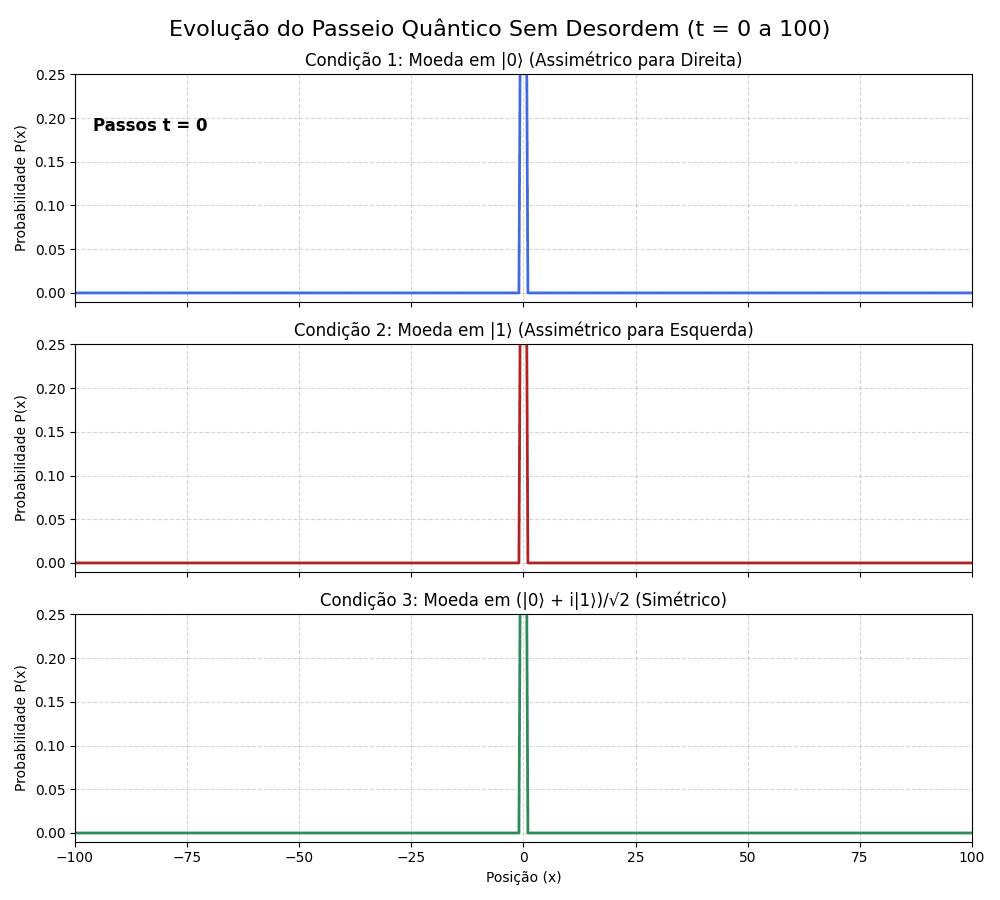

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import Image, display
from IPython.display import HTML
import base64
from IPython.display import HTML

# Configura o matplotlib para renderizar animações via JavaScript
plt.rcParams['animation.html'] = 'jshtml'

# Parâmetros da simulação
T = 100          # Tempo máximo (número de passos)
N = 2 * T + 1    # Tamanho da rede espacial (de -T a T)
origem = T       # Índice central (posição x = 0)

# Eixo x (posições físicas de -100 a 100)
x = np.arange(-T, T + 1)

# Matriz para armazenar as probabilidades: [Condição Inicial, Tempo, Posição]
P = np.zeros((3, T + 1, N))

# 3 Condições Iniciais para o estado da moeda na origem
condicoes_iniciais = [
    np.array([1, 0], dtype=complex),                   # 1: Apenas Direita (|0>)
    np.array([0, 1], dtype=complex),                   # 2: Apenas Esquerda (|1>)
    np.array([1, 1j], dtype=complex) / np.sqrt(2)      # 3: Simétrico (|0> + i|1>)/sqrt(2)
]

# Pré-computando a evolução temporal
for ic_idx, moeda_inicial in enumerate(condicoes_iniciais):
    Psi_Dir = np.zeros(N, dtype=complex)
    Psi_Esq = np.zeros(N, dtype=complex)

    # Condição inicial em t=0 na origem
    Psi_Dir[origem] = moeda_inicial[0]
    Psi_Esq[origem] = moeda_inicial[1]

    P[ic_idx, 0, :] = np.abs(Psi_Dir)**2 + np.abs(Psi_Esq)**2

    for t in range(1, T + 1):
        nova_Dir = (Psi_Dir + Psi_Esq) / np.sqrt(2)
        nova_Esq = (Psi_Dir - Psi_Esq) / np.sqrt(2)

        Psi_Dir = np.roll(nova_Dir, 1)
        Psi_Esq = np.roll(nova_Esq, -1)

        P[ic_idx, t, :] = np.abs(Psi_Dir)**2 + np.abs(Psi_Esq)**2

# ==========================================
# Configuração da Animação
# ==========================================
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
fig.suptitle(f'Evolução do Passeio Quântico Sem Desordem (t = 0 a {T})', fontsize=16)

titulos = [
    "Condição 1: Moeda em |0⟩ (Assimétrico para Direita)",
    "Condição 2: Moeda em |1⟩ (Assimétrico para Esquerda)",
    "Condição 3: Moeda em (|0⟩ + i|1⟩)/√2 (Simétrico)"
]
cores = ['royalblue', 'firebrick', 'seagreen']
linhas = []

# Configuração fixa dos gráficos
for ax, titulo, cor in zip(axes, titulos, cores):
    ax.set_xlim(-T, T)
    ax.set_ylim(-0.01, 0.25) # Limite fixo em Y para observar o formato da onda
    ax.set_ylabel('Probabilidade P(x)')
    ax.set_title(titulo, fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)

    linha, = ax.plot([], [], color=cor, lw=2)
    linhas.append(linha)

axes[-1].set_xlabel('Posição (x)')

# Texto para exibir o relógio de tempo
texto_tempo = axes[0].text(0.02, 0.75, '', transform=axes[0].transAxes, fontsize=12, fontweight='bold')

def init():
    """Inicializa as linhas vazias no começo da animação."""
    for linha in linhas:
        linha.set_data([], [])
    texto_tempo.set_text('')
    return linhas + [texto_tempo]

def animar(t):
    """Atualiza o gráfico para o quadro (tempo) t."""
    for ic_idx, linha in enumerate(linhas):
        linha.set_data(x, P[ic_idx, t, :])

    texto_tempo.set_text(f'Passos t = {t}')
    return linhas + [texto_tempo]

# Cria o objeto de animação
ani = animation.FuncAnimation(
    fig, animar, frames=T + 1, init_func=init,
    interval=50, blit=False, repeat=True
)

plt.tight_layout()
plt.close(fig)

# O writer 'pillow' já vem nativo com o matplotlib e não exige instalação extra (como o ffmpeg)
ani.save('animacao_q4.gif', writer='pillow', fps=20)

# Lê o arquivo GIF gerado e o codifica em base64
with open("animacao_q4.gif", "rb") as f:
    b64_gif = base64.b64encode(f.read()).decode('utf-8')

# Exibe o GIF embutido usando uma tag HTML
display(HTML(f'<img src="data:image/gif;base64,{b64_gif}" />'))

##Q5
Acesse a documentação do [scipy-stats](https://docs.scipy.org/doc/scipy/reference/stats.html) em seguida:

* Escolha 6 distribuições de [variáveis continuas](https://docs.scipy.org/doc/scipy/reference/stats.html#continuous-distributions)  que permitam discutir graficamente a **variância**, **skewness** e **kurtosis** de modo representativo. **Organize os paineis em grid 2x3 usando  [plt.subplots(nrows=2, ncols=3, figsize=(15, 8))](https://www.geeksforgeeks.org/data-visualization/how-to-generate-subplots-with-pythons-matplotlib/)**. Coloque no *título* de cada painel o valor da variância, skewness e kurtosis.


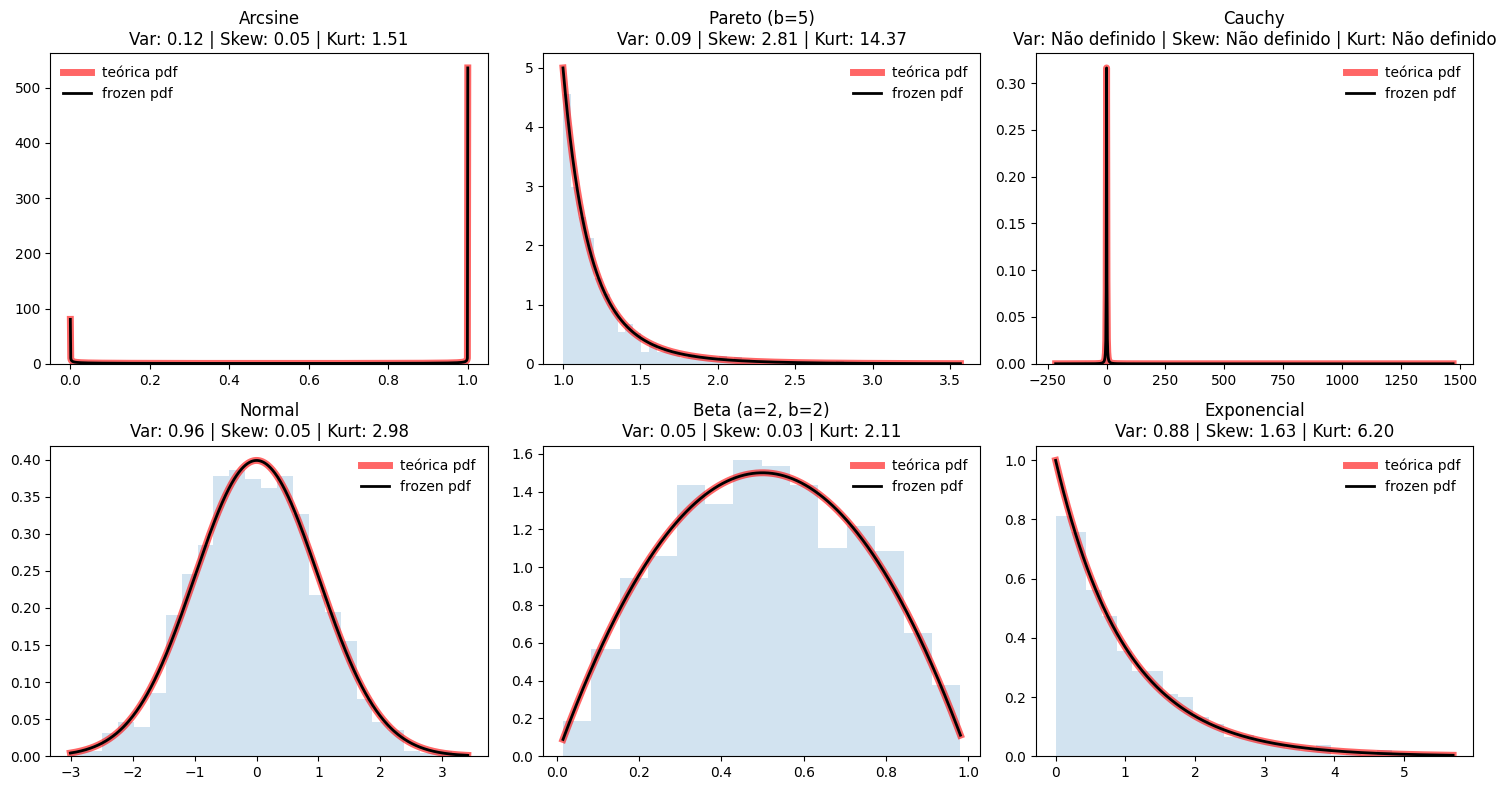

In [3]:
import numpy as np
from scipy.stats import arcsine, pareto, cauchy, norm, beta, expon, skew, kurtosis
import matplotlib.pyplot as plt

# Cria a figura e os eixos em um grid 2x3
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))

# Define as distribuições com seus respectivos parâmetros de forma
distribuicoes = [
    ('Arcsine', arcsine()),
    ('Pareto (b=5)', pareto(b=5)),
    ('Cauchy', cauchy()),
    ('Normal', norm()),
    ('Beta (a=2, b=2)', beta(a=2, b=2)),
    ('Exponencial', expon())
]

# Itera sobre cada painel e distribuição simultaneamente
for ax, (nome, rv) in zip(axes.flatten(), distribuicoes):

    # Gera os números aleatórios (amostra bruta, sem truncar)
    r = rv.rvs(size=1000)

    # Define o eixo x varrendo estritamente o mínimo e máximo dos dados gerados
    x = np.linspace(np.min(r), np.max(r), 1000)

    # Plota as densidades de probabilidade teóricas
    ax.plot(x, rv.pdf(x), 'r-', lw=5, alpha=0.6, label='teórica pdf')
    ax.plot(x, rv.pdf(x), 'k-', lw=2, label='frozen pdf')

    # Plota o histograma com todos os dados sem nenhuma restrição
    ax.hist(r, density=True, bins='auto', histtype='stepfilled', alpha=0.2)

    # Tratamento específico para os momentos teóricos
    if nome == 'Cauchy':
        # Para a Cauchy, os momentos não convergem (são indefinidos)
        ax.set_title(f'{nome}\nVar: Não definido | Skew: Não definido | Kurt: Não definido')
    else:
        # Para as demais, calcula os momentos amostrais reais (fisher=False para curtose padrão)
        var_val = np.var(r)
        skew_val = skew(r)
        kurt_val = kurtosis(r, fisher=False)

        # Formatação de string para lidar com números muito grandes em outras distribuições
        if var_val > 1000 or kurt_val > 1000:
            ax.set_title(f'{nome}\nVar: {var_val:.2e} | Skew: {skew_val:.2e} | Kurt: {kurt_val:.2e}')
        else:
            ax.set_title(f'{nome}\nVar: {var_val:.2f} | Skew: {skew_val:.2f} | Kurt: {kurt_val:.2f}')

    ax.legend(loc='best', frameon=False)

# Ajusta o layout para evitar sobreposições
plt.tight_layout()
plt.show()

##Q6
Acesse a documentação do [scipy-stats](https://docs.scipy.org/doc/scipy/reference/stats.html) em seguida:

* Escolha 6 distribuições de [variáveis discretas](https://docs.scipy.org/doc/scipy/reference/stats.html#discrete-distributions) que permitam discutir graficamente a **variância**, **skewness** e **kurtosis** de modo representativo. **Organize os paineis em grid 2x3 usando  [plt.subplots(nrows=2, ncols=3, figsize=(15, 8))](https://www.geeksforgeeks.org/data-visualization/how-to-generate-subplots-with-pythons-matplotlib/)**. Coloque no *título* de cada painel o valor da variância, skewness e kurtosis.




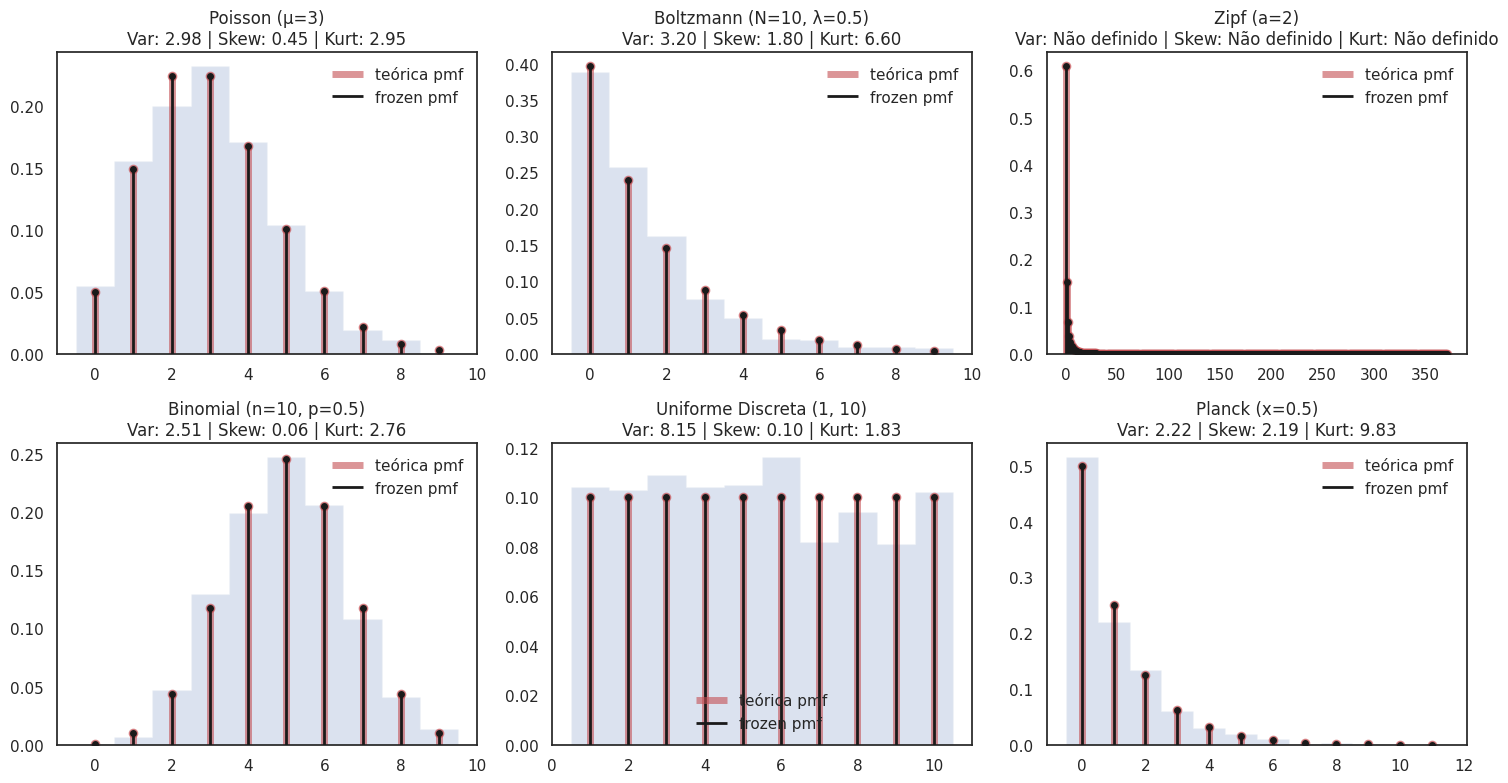

In [ ]:
import numpy as np
from scipy.stats import poisson, boltzmann, zipf, binom, randint, rv_discrete, skew, kurtosis
import matplotlib.pyplot as plt

# 1. Custom construction for the Planck Distribution
# The Planck distribution (Bose-Einstein statistics for a single mode) is equivalent
# to a Geometric distribution starting at 0. P(n) = (1-x) * x^n, where x = exp(-E/kT).
# Let's use x = 0.5 for this example.
x_planck = 0.5
class planck_gen(rv_discrete):
    def _pmf(self, k, x):
        return (1 - x) * (x ** k)

planck = planck_gen(name='planck', a=0)

# 2. Create the figure and axes in a 2x3 grid
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))

# 3. Define the discrete distributions with their respective parameters
distribuicoes = [
    ('Poisson (μ=3)', poisson(mu=3)),
    ('Boltzmann (N=10, λ=0.5)', boltzmann(lambda_=0.5, N=10)),
    ('Zipf (a=2)', zipf(a=2)),
    ('Binomial (n=10, p=0.5)', binom(n=10, p=0.5)),
    ('Uniforme Discreta (1, 10)', randint(low=1, high=11)),
    ('Planck (x=0.5)', planck(x=0.5))
]

# 4. Iterate over each panel
for ax, (nome, rv) in zip(axes.flatten(), distribuicoes):

    # Generate random numbers (integers for discrete distributions)
    r = rv.rvs(size=1000)

    # Define the x-axis covering the strictly generated integer values
    x_min = np.min(r)
    x_max = np.max(r)
    x = np.arange(x_min, x_max + 1)

    # Plot the theoretical PMF using vertical lines and dots (standard for discrete)
    ax.vlines(x, 0, rv.pmf(x), colors='r', lw=5, alpha=0.6, label='teórica pmf')
    ax.plot(x, rv.pmf(x), 'ro', alpha=0.6)

    # Plot the "frozen" PMF (overlayed thin black line for visual contrast)
    ax.vlines(x, 0, rv.pmf(x), colors='k', linestyles='-', lw=2, label='frozen pmf', zorder=3)
    ax.plot(x, rv.pmf(x), 'ko', markersize=4, zorder=4)

    # Plot histogram of the sample.
    # Center bins on integers to avoid misalignment in discrete data!
    bins = np.arange(x_min - 0.5, x_max + 1.5, 1)
    ax.hist(r, density=True, bins=bins, histtype='stepfilled', alpha=0.2)

    # 5. Calculate and format statistical moments
    if nome.startswith('Zipf'):
         # Zipf (a=2) has undefined moments, just like Cauchy
         ax.set_title(f'{nome}\nVar: Não definido | Skew: Não definido | Kurt: Não definido')
    else:
        var_val = np.var(r)
        skew_val = skew(r)
        kurt_val = kurtosis(r, fisher=False) # Fisher=False for standard Pearson kurtosis

        if var_val > 1000 or kurt_val > 1000:
            ax.set_title(f'{nome}\nVar: {var_val:.2e} | Skew: {skew_val:.2e} | Kurt: {kurt_val:.2e}')
        else:
            ax.set_title(f'{nome}\nVar: {var_val:.2f} | Skew: {skew_val:.2f} | Kurt: {kurt_val:.2f}')

    ax.legend(loc='best', frameon=False)

# Adjust layout and show
plt.tight_layout()
plt.show()